# Bachelorproef — POC: Automatische detectie van open/gesloten status van supermarkten

**Auteur:** Maxim Van Der Schueren  
**Academiejaar:** 2025–2026   

---

**Labelstrategie:**
- `is_active = 1` → open
- `is_active = 0` → gesloten (scraper was actief maar registreerde POI als inactief)
- `is_deleted = 1` → extra feature, **niet** als label

---
## 0. Configuratie & bibliotheken

Pas `DATA_PATH` aan om te wisselen tussen de Delhaize-testset en de volledige dataset.

In [ ]:
DATA_PATH   = "../../data accurat/info louis d en delhaize.csv"  
MODEL_DIR   = "./models"         
RANDOM_SEED = 42
TEST_SIZE   = 0.2

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
import joblib

import xgboost as xgb
import holidays

---
## 1. Data inladen

De data is een CSV-export van drie samengevoegde tabellen:
- **status_history** — historische open/gesloten registraties (`is_active`, `start`, `end`)
- **POI basisinfo** — naam, adres, categorie, merk, …
- **openingsuren** — verwachte openingstijden per dag (`day_of_week`, `stop`, `pause_start`, `pause_stop`, …)

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Geladen: {df_raw.shape[0]:,} rijen × {df_raw.shape[1]} kolommen")
df_raw.head(3)

Geladen: 44,384 rijen × 51 kolommen


,id,poi_id,status_start,status_end,is_active,inserted_at,updated_at,id.1,name,street,...,pause_stop,opening_stop,appointment,closed,ok,inserted_at.2,updated_at.2,date,start_valid,end_valid
0,946095,389058,NaN,2023-09-30,0,2024-08-02 13:46:25,2024-08-02 13:46:25,389058,Delhaize,Chaussée de Tournai,...,NaN,19:00:00,NaN,0,1.0,2024-08-02 11:42:08,2024-08-02 11:42:08,NaN,NaN,NaN
1,946095,389058,NaN,2023-09-30,0,2024-08-02 13:46:25,2024-08-02 13:46:25,389058,Delhaize,Chaussée de Tournai,...,NaN,18:00:00,NaN,0,1.0,2025-06-26 07:01:05,2025-06-26 07:01:05,NaN,2023-12-25,2023-12-25
2,946095,389058,NaN,2023-09-30,0,2024-08-02 13:46:25,2024-08-02 13:46:25,389058,Delhaize,Chaussée de Tournai,...,NaN,18:00:00,NaN,0,1.0,2025-06-26 07:09:17,2025-06-26 07:09:17,NaN,2024-01-01,2024-01-01


In [3]:
df_raw.dtypes

id                    int64
poi_id                int64
status_start         object
status_end           object
is_active             int64
inserted_at          object
updated_at           object
id.1                  int64
name                 object
street               object
nbr                  object
box                  object
zip                   int64
city                 object
country              object
priority            float64
source               object
source_id            object
point                object
polygon              object
is_active.1           int64
visit                 int64
work                  int64
main_category_id    float64
brand_id            float64
inserted_at.1        object
updated_at.1         object
district_id         float64
client_id           float64
description         float64
is_sensitive          int64
pass                  int64
poi_parent_id       float64
cluster               int64
is_deleted            int64
is_reserved_poi     

In [4]:
# Ontbrekende waarden per kolom
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "percentage": missing_pct})
missing_df[missing_df["missing"] > 0].sort_values("percentage", ascending=False)

,missing,percentage
description,44384,100.00
date,44384,100.00
main_category_id,44384,100.00
district_id,44384,100.00
poi_parent_id,44384,100.00
client_id,44363,99.95
pause_start,43798,98.68
pause_stop,43793,98.67
appointment,43529,98.07
box,42052,94.75


In [5]:
df = df_raw.copy()

# Kolommen met 100% ontbrekende waarden verwijderen 
volledig_leeg = df.columns[df.isnull().mean() == 1.0].tolist()
if volledig_leeg:
    df.drop(columns=volledig_leeg, inplace=True)
    print(f"Verwijderde kolommen: {volledig_leeg}")

Verwijderde kolommen: ['main_category_id', 'district_id', 'description', 'poi_parent_id', 'date']


In [7]:
# Datumkolommen parsen
for col in ["status_start", "status_end", "updated_at", "start_valid", "end_valid"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df.dtypes

id                          int64
poi_id                      int64
status_start       datetime64[ns]
status_end         datetime64[ns]
is_active                   int64
inserted_at                object
updated_at         datetime64[ns]
id.1                        int64
name                       object
street                     object
nbr                        object
box                        object
zip                         int64
city                       object
country                    object
priority                  float64
source                     object
source_id                  object
point                      object
polygon                    object
is_active.1                 int64
visit                       int64
work                        int64
brand_id                  float64
inserted_at.1              object
updated_at.1               object
client_id                 float64
is_sensitive                int64
pass                        int64
cluster       

# 2. Data analyse

### 2.1 Verdeling open / gesloten

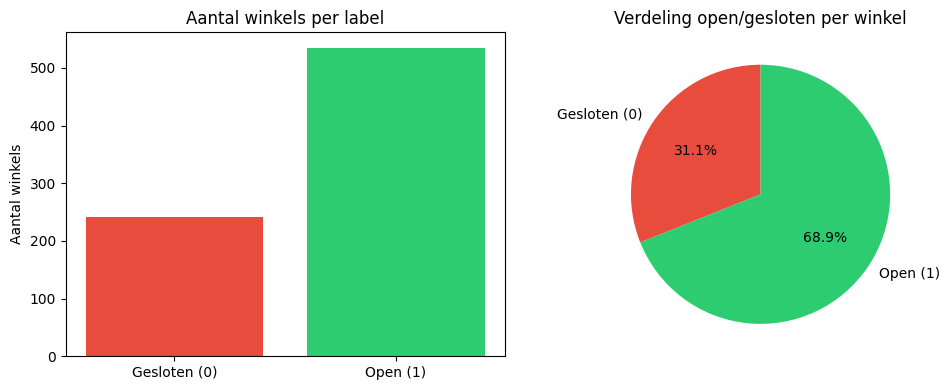

           aantal  percentage
is_active                    
0             241       31.06
1             535       68.94


In [35]:
df_basis = pd.read_csv("../../data accurat/combined basisinfo.csv", low_memory=False)

label_counts = df_basis["is_active"].value_counts().sort_index()
label_pct    = label_counts / len(df_basis) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Gesloten (0)", "Open (1)"], label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Aantal winkels per label")
axes[0].set_ylabel("Aantal winkels")

axes[1].pie(label_counts.values, labels=["Gesloten (0)", "Open (1)"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Verdeling open/gesloten per winkel")

plt.tight_layout()
plt.show()

print(label_counts.to_frame("aantal").assign(percentage=label_pct.round(2)))

### 2.2 Verdeling per merk 

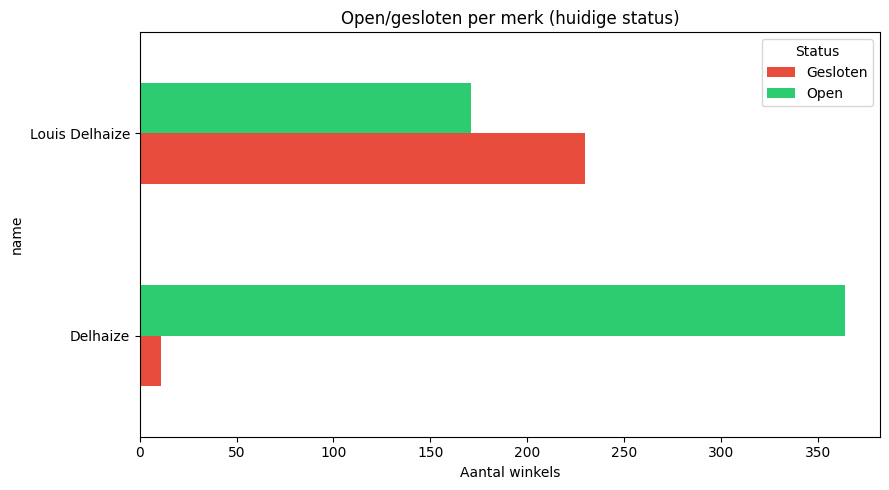

In [36]:
brand_status = (df_basis.groupby("name")["is_active"]
                        .value_counts()
                        .unstack(fill_value=0)
                        .rename(columns={0: "Gesloten", 1: "Open"}))

brand_status.plot(kind="barh", figsize=(9, 5), color=["#e74c3c", "#2ecc71"])
plt.xlabel("Aantal winkels")
plt.title("Open/gesloten per merk (huidige status)")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

# 3. Feature engineering


In [8]:
df["maand"]      = df["updated_at"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [9]:
df["start_min"] = df["opening_start"].fillna("0:00:00").apply(lambda x: int(x.split(":")[0]) * 60 + int(x.split(":")[1]))
df["stop_min"]  = df["opening_stop"].fillna("0:00:00").apply(lambda x: int(x.split(":")[0]) * 60 + int(x.split(":")[1]))
df["verwachte_openingsduur_min"] = df["stop_min"] - df["start_min"]

In [10]:
df["is_deleted"] = df["is_deleted"].astype(int)

In [11]:
le = LabelEncoder()
df["brand_id_enc"] = le.fit_transform(df["brand_id"].astype(str))
df["country_enc"]  = le.fit_transform(df["country"].astype(str))

In [12]:
df["is_feestdag"] = df["start_valid"].notna().astype(int)

In [16]:
df = df.sort_values(['poi_id', 'updated_at'])
df['historisch_inactief_count'] = df.groupby('poi_id')['is_active'].transform(lambda x: x.eq(0).cumsum())
df['inactiviteit_ratio'] = df.groupby('poi_id')['is_active'].transform(lambda x: x.eq(0).sum() / len(x))
df['poi_leeftijd_maanden'] = ((df['updated_at'] - df.groupby('poi_id')['updated_at'].transform('min')).dt.days / 30).round().astype(int)

In [17]:
FEATURE_COLS = [
    col for col in [
        "maand", "is_weekend", "is_feestdag",
        "start_min", "stop_min", "verwachte_openingsduur_min",
        "is_deleted", "is_sensitive", "is_reserved_poi", "cluster",
        "brand_id_enc", "country_enc", "visit", "work", "closed", 
        "ok", "day_of_week", "historisch_inactief_count", 'inactiviteit_ratio', "poi_leeftijd_maanden",
    ]
    if col in df.columns
]

TARGET_COL = "is_active"

---
## 4. Train/test-splitsing

In [18]:
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna(subset=[TARGET_COL])

df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median(numeric_only=True))

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Label-verdeling train — open: {y_train.mean():.2%}")
print(f"Label-verdeling test  — open: {y_test.mean():.2%}")

Train: 35,507 | Test: 8,877
Label-verdeling train — open: 51.47%
Label-verdeling test  — open: 51.47%


---
## 5. Hulpfuncties

In [20]:
def evalueer_model(naam, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"Model: {naam}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Gesloten", "Open"]))

    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                   display_labels=["Gesloten", "Open"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion matrix — {naam}")
    plt.tight_layout()
    plt.show()

    return {"model": naam, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


def plot_feature_importance(naam, model, feature_names, top_n=15):
    importances = model.feature_importances_
    idx = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(8, max(4, top_n * 0.35)))
    plt.barh(np.array(feature_names)[idx], importances[idx], color="#2980b9")
    plt.xlabel("Feature importance")
    plt.title(f"Top {top_n} features — {naam}")
    plt.tight_layout()
    plt.show()


resultaten = []  

---
## 6. Model 1 — Random Forest

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=200, n_jobs=-1, random_state=42)


Model: Random Forest
Accuracy : 0.9500
Precision: 0.9697
Recall   : 0.9319
F1-score : 0.9504
              precision    recall  f1-score   support

    Gesloten       0.93      0.97      0.95      4308
        Open       0.97      0.93      0.95      4569

    accuracy                           0.95      8877
   macro avg       0.95      0.95      0.95      8877
weighted avg       0.95      0.95      0.95      8877



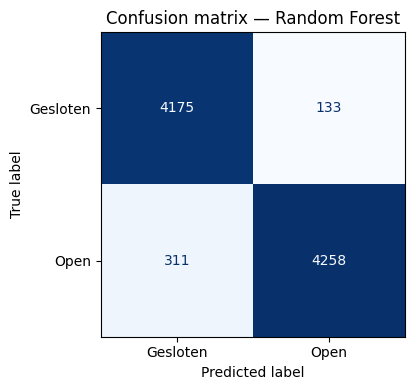

In [22]:
rf_metrics = evalueer_model("Random Forest", rf, X_test, y_test)
resultaten.append(rf_metrics)

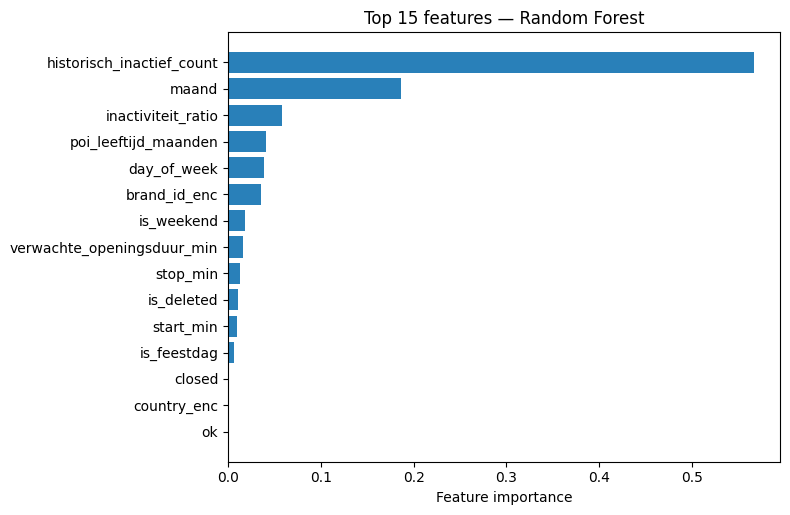

In [23]:
plot_feature_importance("Random Forest", rf, FEATURE_COLS)

In [24]:
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.joblib"))

['./models\\random_forest.joblib']

---
## 7. Model 2 — XGBoost

In [25]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos if pos > 0 else 1

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


Model: XGBoost
Accuracy : 0.9537
Precision: 0.9664
Recall   : 0.9429
F1-score : 0.9545
              precision    recall  f1-score   support

    Gesloten       0.94      0.97      0.95      4308
        Open       0.97      0.94      0.95      4569

    accuracy                           0.95      8877
   macro avg       0.95      0.95      0.95      8877
weighted avg       0.95      0.95      0.95      8877



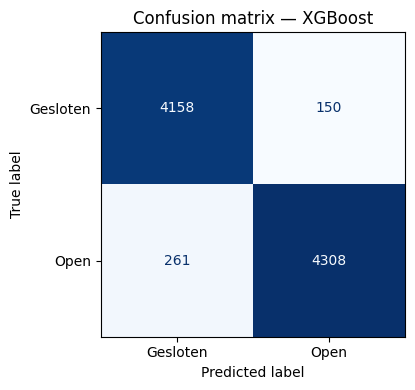

In [26]:
xgb_metrics = evalueer_model("XGBoost", xgb_model, X_test, y_test)
resultaten.append(xgb_metrics)

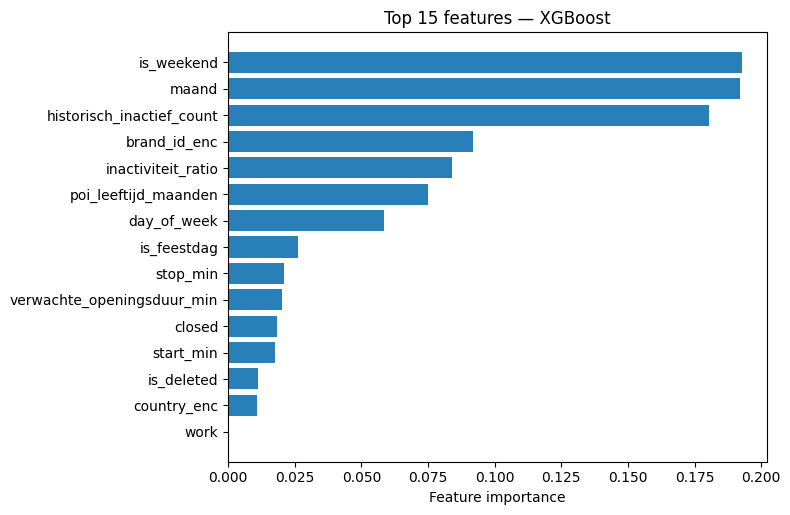

In [27]:
plot_feature_importance("XGBoost", xgb_model, FEATURE_COLS)

In [29]:
joblib.dump(xgb_model, os.path.join(MODEL_DIR, "xgboost.joblib"))

['./models\\xgboost.joblib']

## 8. Model 3 — Logistic Regression

In [36]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_SEED
)
lr.fit(X_train, y_train)

c:\Users\Maxim\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


Model: Logistic Regression
Accuracy : 0.6049
Precision: 0.6672
Recall   : 0.4638
F1-score : 0.5472
              precision    recall  f1-score   support

    Gesloten       0.57      0.75      0.65      4308
        Open       0.67      0.46      0.55      4569

    accuracy                           0.60      8877
   macro avg       0.62      0.61      0.60      8877
weighted avg       0.62      0.60      0.60      8877



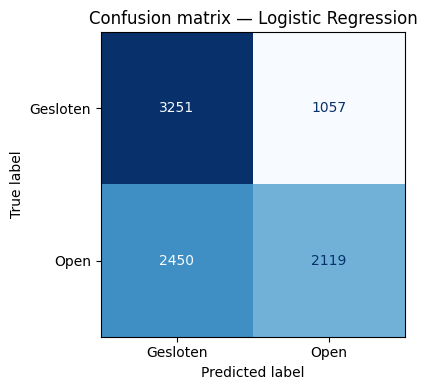

In [37]:
lr_metrics = evalueer_model("Logistic Regression", lr, X_test, y_test)
resultaten.append(lr_metrics)

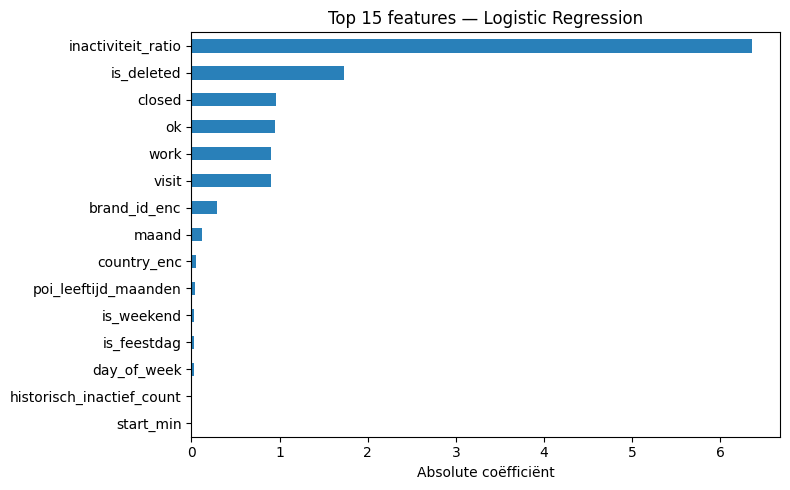

In [38]:
coef = pd.Series(lr.coef_[0], index=FEATURE_COLS).abs().sort_values(ascending=True)
coef.tail(15).plot(kind="barh", figsize=(8, 5), color="#2980b9")
plt.xlabel("Absolute coëfficiënt")
plt.title("Top 15 features — Logistic Regression")
plt.tight_layout()
plt.show()

In [39]:
joblib.dump(lr, os.path.join(MODEL_DIR, "logistic_regression.joblib"))

['./models\\logistic_regression.joblib']

---
## 9. Modelvergelijking

In [44]:
df_resultaten = pd.DataFrame(resultaten)
df_resultaten = df_resultaten.drop_duplicates(subset=["model"])
df_resultaten = df_resultaten.set_index("model")
df_resultaten = df_resultaten.rename(columns={
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall",
    "f1"       : "F1-score"
})

display(df_resultaten.style.format("{:.4f}"))

,Accuracy,Precision,Recall,F1-score
model,,,,
Random Forest,0.9500,0.9697,0.9319,0.9504
XGBoost,0.9537,0.9664,0.9429,0.9545
Logistic Regression,0.6049,0.6672,0.4638,0.5472


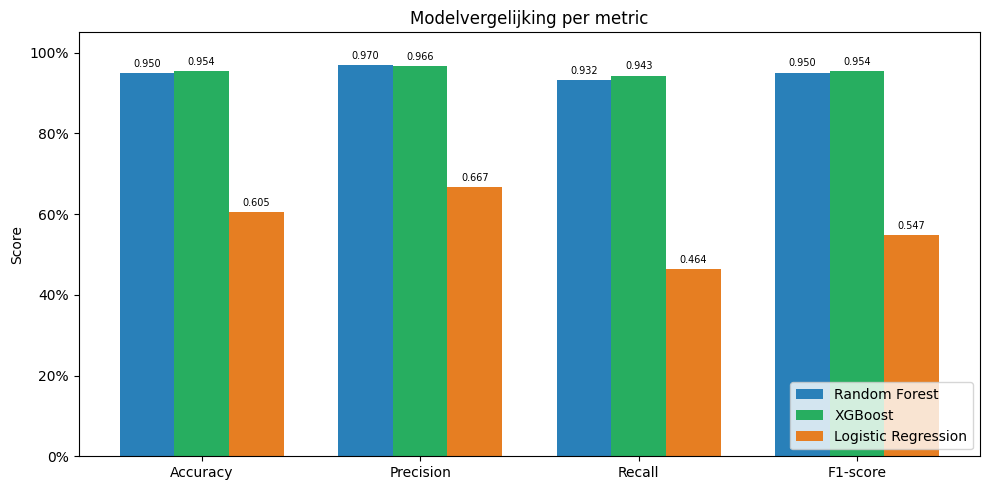

In [45]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x       = np.arange(len(metrics))
width   = 0.25
kleuren = ["#2980b9", "#27ae60", "#e67e22"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (naam, rij) in enumerate(df_resultaten.iterrows()):
    ax.bar(x + i * width, rij[metrics].values, width, label=naam, color=kleuren[i % len(kleuren)])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Modelvergelijking per metric")
ax.legend(loc="lower right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Waarde-labels boven de balken
for patch in ax.patches:
    h = patch.get_height()
    ax.annotate(f"{h:.3f}",
                xy=(patch.get_x() + patch.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()